
# Demo: Strike, Dip, Rake, Stereonets, and Beachballs

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/demos/08_beachball_demo.ipynb)

This demo has three goals:

1. Plot a fault plane from **strike** and **dip** on a lower-hemisphere stereonet.
2. Add a **rake** lineation on that plane.
3. Use the same strike-dip-rake values to draw the corresponding double-couple **beachball** focal mechanism.

The code intentionally avoids specialized geology/seismology plotting packages so students can see the geometry directly.


In [1]:

# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except Exception:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'ipywidgets': 'ipywidgets'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

# Colab sometimes needs this for interactive widgets.
if IN_COLAB:
    try:
        from google.colab import output
        output.enable_custom_widget_manager()
        print("✓ Enabled Colab widget manager")
    except Exception as exc:
        print(f"Widget manager note: {exc}")


Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ ipywidgets is already installed

✓ All required packages are installed!


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from ipywidgets import interact, FloatSlider, Dropdown, Layout



## Coordinate and sign conventions

This notebook uses common seismological conventions for a double-couple fault source:

- **Strike** is measured clockwise from north, in degrees.
- **Dip** is measured down from horizontal, in degrees. The plane dips to the right of the strike direction.
- **Rake** is measured within the fault plane, in degrees.
  - `rake = 0°` and `rake = 180°` are strike-slip end members.
  - `rake = +90°` is reverse/thrust slip.
  - `rake = -90°` is normal slip.
- The stereonet and beachball are both shown as **lower-hemisphere equal-area projections**.
- On the beachball, black regions mark positive/compressional P-wave first motion in this convention.

A stereonet point for the rake lineation shows the orientation of the slip line, but not the sign of slip by itself. The beachball carries the slip sense through the black/white polarity pattern.


Define the fault-plane geometry and projection helpers.

In [3]:

DEG = np.pi / 180.0


def unit_vector(v):
    """Return a unit vector."""
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("Cannot normalize a zero-length vector")
    return v / norm


def fault_vectors(strike, dip, rake):
    """
    Return useful vectors for a fault defined by strike, dip, and rake.

    Coordinate system is NED:
        component 0 = North
        component 1 = East
        component 2 = Down

    The stereonet basis uses a down-dip vector, while the focal-mechanism
    slip vector follows the seismological convention in which +90 rake is
    reverse/thrust slip and -90 rake is normal slip.
    """
    phi = strike * DEG
    delta = dip * DEG
    lam = rake * DEG

    # Horizontal vector along strike, positive in the strike azimuth.
    strike_vec = np.array([np.cos(phi), np.sin(phi), 0.0])

    # Down-dip vector for a right-hand-rule plane.
    down_dip_vec = np.array([
        -np.sin(phi) * np.cos(delta),
         np.cos(phi) * np.cos(delta),
         np.sin(delta)
    ])

    # Lower-hemisphere pole to the plane.
    pole_down = unit_vector(np.cross(strike_vec, down_dip_vec))
    if pole_down[2] < 0:
        pole_down = -pole_down

    # Upward-pointing normal used in the focal-mechanism convention.
    normal = np.array([
        -np.sin(delta) * np.sin(phi),
         np.sin(delta) * np.cos(phi),
        -np.cos(delta)
    ])

    # Slip vector: +90 rake gives reverse/thrust slip.
    slip = np.array([
        np.cos(lam) * np.cos(phi) + np.sin(lam) * np.cos(delta) * np.sin(phi),
        np.cos(lam) * np.sin(phi) - np.sin(lam) * np.cos(delta) * np.cos(phi),
       -np.sin(lam) * np.sin(delta)
    ])

    return {
        "strike": unit_vector(strike_vec),
        "down_dip": unit_vector(down_dip_vec),
        "pole_down": unit_vector(pole_down),
        "normal": unit_vector(normal),
        "slip": unit_vector(slip),
    }


def lower_hemisphere(v):
    """Flip vector(s) to the lower hemisphere, where Down >= 0."""
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        v = unit_vector(v)
        return -v if v[2] < 0 else v

    norms = np.linalg.norm(v, axis=1)
    out = v / norms[:, None]
    flip = out[:, 2] < 0
    out[flip] *= -1
    return out


def project_equal_area(v):
    """
    Lower-hemisphere equal-area projection.

    Input vectors use NED coordinates. Output x is East and output y is North.
    The primitive circle has radius 1.
    """
    v = np.asarray(v, dtype=float)
    single_vector = (v.ndim == 1)
    if single_vector:
        v = v[None, :]

    v = lower_hemisphere(v)
    N = v[:, 0]
    E = v[:, 1]
    D = np.clip(v[:, 2], -1.0, 1.0)

    horizontal = np.hypot(N, E)
    theta = np.arccos(D)  # angle from vertical down
    rho = np.sqrt(2.0) * np.sin(theta / 2.0)

    x = np.zeros_like(rho)
    y = np.zeros_like(rho)
    ok = horizontal > 1e-12
    x[ok] = rho[ok] * E[ok] / horizontal[ok]
    y[ok] = rho[ok] * N[ok] / horizontal[ok]

    if single_vector:
        return x[0], y[0]
    return x, y


def trend_plunge(v):
    """Return trend and plunge, in degrees, for a lower-hemisphere lineation."""
    v = lower_hemisphere(v)
    N, E, D = v
    trend = (np.degrees(np.arctan2(E, N)) + 360.0) % 360.0
    plunge = np.degrees(np.arctan2(D, np.hypot(N, E)))
    return trend, plunge


Set up a simple equal-area stereonet and plot strike, dip, pole, and rake lineation.

In [4]:

def setup_stereonet(ax, title="Lower-hemisphere equal-area stereonet"):
    """Draw a simple lower-hemisphere equal-area stereonet background."""
    ax.set_aspect("equal")
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)
    ax.axis("off")

    # Primitive circle.
    ax.add_patch(Circle((0, 0), 1, fill=False, linewidth=1.8, color="black"))

    # Constant-plunge circles for lineations.
    for plunge in [15, 30, 45, 60, 75]:
        theta = (90.0 - plunge) * DEG
        radius = np.sqrt(2.0) * np.sin(theta / 2.0)
        ax.add_patch(Circle((0, 0), radius, fill=False, linewidth=0.6, color="0.82"))
        ax.text(0.02, radius + 0.015, f"{plunge}°", color="0.55", fontsize=8)

    # Trend lines every 30 degrees.
    for az in np.arange(0, 360, 30):
        a = az * DEG
        ax.plot([0, np.sin(a)], [0, np.cos(a)], color="0.88", linewidth=0.6)

    ax.text(0, 1.045, "N", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.text(1.045, 0, "E", ha="left", va="center", fontsize=11, fontweight="bold")
    ax.text(0, -1.045, "S", ha="center", va="top", fontsize=11, fontweight="bold")
    ax.text(-1.045, 0, "W", ha="right", va="center", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12)


def plane_great_circle(strike, dip, npts=181):
    """Projected great circle of a right-hand-rule fault plane."""
    vecs = fault_vectors(strike, dip, rake=0)
    strike_vec = vecs["strike"]
    down_dip_vec = vecs["down_dip"]

    # The half great circle from one strike direction to the opposite strike
    # direction stays on the lower hemisphere for 0 <= t <= pi.
    t = np.linspace(0.0, np.pi, npts)
    line_vectors = np.cos(t)[:, None] * strike_vec + np.sin(t)[:, None] * down_dip_vec
    return project_equal_area(line_vectors)


def plot_stereonet(strike=0, dip=60, rake=-90, ax=None):
    """Plot fault plane, pole, and rake lineation on a stereonet."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    setup_stereonet(ax)

    vectors = fault_vectors(strike, dip, rake)

    # Fault plane as a great circle.
    x_plane, y_plane = plane_great_circle(strike, dip)
    ax.plot(x_plane, y_plane, linewidth=2.5, color="tab:blue", label="fault plane")

    # Pole to the plane.
    pole_x, pole_y = project_equal_area(vectors["pole_down"])
    ax.plot(pole_x, pole_y, marker="s", markersize=7, color="tab:red", label="pole to plane")

    # Rake/slip lineation.
    slip_lower = lower_hemisphere(vectors["slip"])
    slip_x, slip_y = project_equal_area(slip_lower)
    ax.plot(slip_x, slip_y, marker="*", markersize=13, color="tab:green", label="rake lineation")

    pole_trend, pole_plunge = trend_plunge(vectors["pole_down"])
    slip_trend, slip_plunge = trend_plunge(slip_lower)

    info = (
        f"strike={strike:.0f}°, dip={dip:.0f}°, rake={rake:.0f}°\n"
        f"pole: {pole_trend:.0f}/{pole_plunge:.0f}\n"
        f"slip line: {slip_trend:.0f}/{slip_plunge:.0f}"
    )
    ax.text(
        -1.02, -1.18, info,
        ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.75")
    )

    ax.legend(loc="lower right", bbox_to_anchor=(1.08, -0.12), fontsize=9)
    return ax


Example: plot one fault plane on the stereonet.

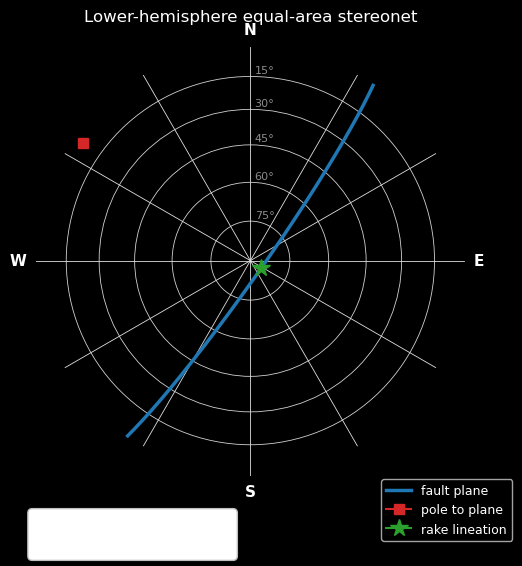

In [14]:
plot_stereonet(strike=35, dip=85, rake=-90)
plt.show()


Build a beachball from the strike-dip-rake double-couple moment tensor.

In [6]:

def moment_tensor(strike, dip, rake):
    """
    Double-couple moment tensor from strike, dip, and rake.

    The tensor is returned in NED coordinates: North, East, Down.
    The scalar moment is normalized away because only the polarity pattern is
    needed for a beachball.
    """
    vectors = fault_vectors(strike, dip, rake)
    slip = vectors["slip"]
    normal = vectors["normal"]
    M = np.outer(slip, normal) + np.outer(normal, slip)
    M = 0.5 * (M + M.T)
    scale = np.max(np.abs(M))
    if scale > 0:
        M = M / scale
    return M


def focal_sphere_grid(n=301):
    """Create a projected lower-focal-sphere grid in NED coordinates."""
    x = np.linspace(-1.0, 1.0, n)  # East on plot
    y = np.linspace(-1.0, 1.0, n)  # North on plot
    X, Y = np.meshgrid(x, y)
    rho = np.hypot(X, Y)
    mask = rho <= 1.0

    # Equal-area inverse projection.
    theta = 2.0 * np.arcsin(np.clip(rho / np.sqrt(2.0), 0.0, 1.0 / np.sqrt(2.0)))
    horizontal = np.sin(theta)
    D = np.cos(theta)

    denom = np.where(rho > 1e-12, rho, 1.0)
    E = horizontal * X / denom
    N = horizontal * Y / denom
    N[~mask] = np.nan
    E[~mask] = np.nan
    D[~mask] = np.nan
    return X, Y, N, E, D, mask


def radiation_pattern(M, n=301):
    """P-wave first-motion radiation pattern on the lower focal sphere."""
    X, Y, N, E, D, mask = focal_sphere_grid(n=n)
    A = (
        M[0, 0] * N * N + M[1, 1] * E * E + M[2, 2] * D * D
        + 2.0 * M[0, 1] * N * E
        + 2.0 * M[0, 2] * N * D
        + 2.0 * M[1, 2] * E * D
    )
    A[~mask] = np.nan
    return X, Y, A, mask


def principal_axes(M):
    """Return lower-hemisphere P and T axes from a moment tensor."""
    values, vectors = np.linalg.eigh(M)
    P_axis = lower_hemisphere(vectors[:, np.argmin(values)])
    T_axis = lower_hemisphere(vectors[:, np.argmax(values)])
    return P_axis, T_axis


def plot_beachball(strike=0, dip=60, rake=-90, ax=None, resolution=301, show_axes=True):
    """Draw a simple lower-hemisphere beachball."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    M = moment_tensor(strike, dip, rake)
    X, Y, A, mask = radiation_pattern(M, n=resolution)
    finite = np.isfinite(A)
    vmax = np.nanmax(np.abs(A[finite]))
    if vmax == 0:
        vmax = 1.0

    # White = dilatation/negative; black = compression/positive.
    ax.contourf(X, Y, A, levels=[-vmax, 0, vmax], colors=["white", "black"])
    ax.contour(X, Y, A, levels=[0], colors="black", linewidths=1.0)
    ax.add_patch(Circle((0, 0), 1, fill=False, linewidth=1.8, color="black"))

    if show_axes:
        P_axis, T_axis = principal_axes(M)
        p_x, p_y = project_equal_area(P_axis)
        t_x, t_y = project_equal_area(T_axis)
        ax.plot(p_x, p_y, marker="o", markersize=7, markerfacecolor="white", markeredgecolor="black")
        ax.text(
            p_x + 0.035, p_y + 0.035, "P", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.8)
        )
        ax.plot(
            t_x, t_y, marker="o", markersize=7,
            markerfacecolor="black", markeredgecolor="white", markeredgewidth=1.2
        )
        ax.text(
            t_x + 0.035, t_y + 0.035, "T", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.8)
        )

    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.axis("off")
    ax.set_title(f"Beachball: {strike:.0f}/{dip:.0f}/{rake:.0f}", fontsize=12)
    return ax


Example: draw one beachball.

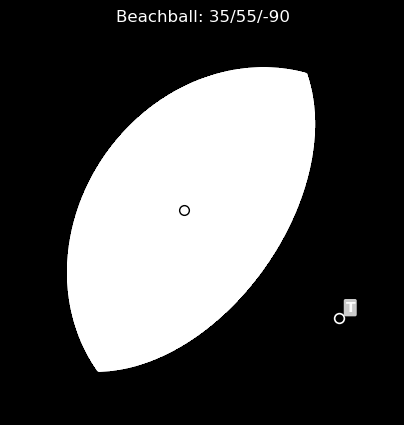

In [7]:

plot_beachball(strike=35, dip=55, rake=-90)
plt.show()


Combine the stereonet and beachball in a single figure.

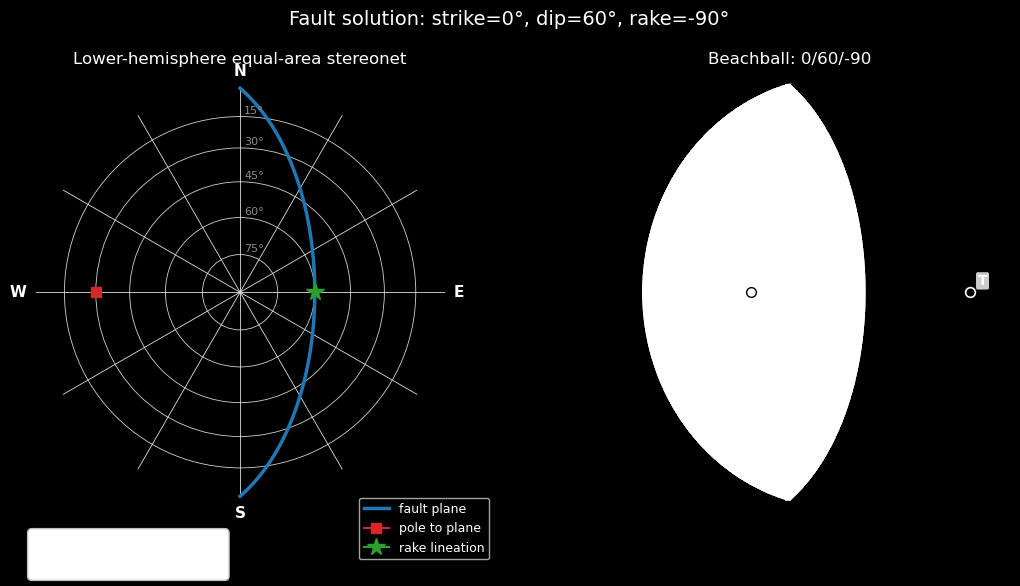

In [8]:

def plot_fault_solution(strike=0, dip=60, rake=-90):
    """Plot stereonet and beachball side by side for one fault solution."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    plot_stereonet(strike=strike, dip=dip, rake=rake, ax=axes[0])
    plot_beachball(strike=strike, dip=dip, rake=rake, ax=axes[1], resolution=251)

    fig.suptitle(
        f"Fault solution: strike={strike:.0f}°, dip={dip:.0f}°, rake={rake:.0f}°",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()


plot_fault_solution(strike=0, dip=60, rake=-90)



## Interactive fault solution

Move the sliders to change the fault geometry. Try these checks:

- Keep strike and dip fixed, then move rake from `-90°` to `+90°`. The stereonet lineation stays on the same plane, but the beachball polarity pattern changes from normal to reverse.
- Set `dip = 90°` and compare `rake = 0°` with `rake = 180°`.
- Set rake to values such as `-45°` or `+135°` to make oblique-slip mechanisms.


In [9]:

slider_style = {"description_width": "70px"}
slider_layout = Layout(width="480px")

interact(
    plot_fault_solution,
    strike=FloatSlider(
        min=0, max=360, step=1, value=0,
        description="Strike", style=slider_style, layout=slider_layout,
        continuous_update=False
    ),
    dip=FloatSlider(
        min=1, max=90, step=1, value=60,
        description="Dip", style=slider_style, layout=slider_layout,
        continuous_update=False
    ),
    rake=FloatSlider(
        min=-180, max=180, step=1, value=-90,
        description="Rake", style=slider_style, layout=slider_layout,
        continuous_update=False
    )
);


interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Strike', layout=Layout(widt…


## Common source types

The same code can represent different faulting sources by changing only strike, dip, and rake. The examples below use simple reference orientations so the end members are easy to compare.


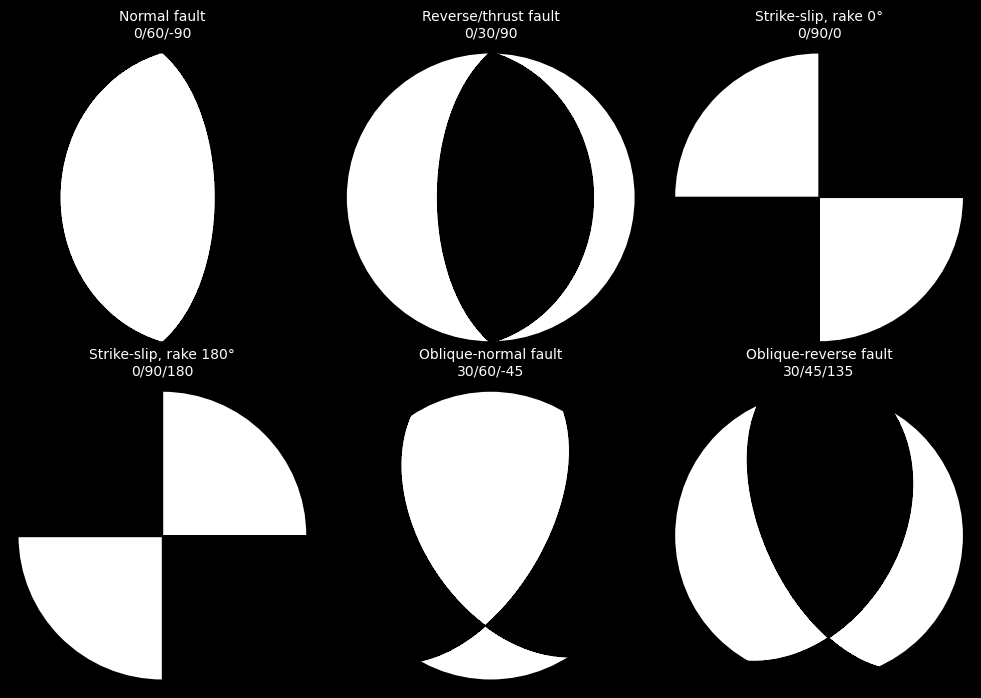

In [10]:

source_presets = {
    "Normal fault": (0, 60, -90),
    "Reverse/thrust fault": (0, 30, 90),
    "Strike-slip, rake 0°": (0, 90, 0),
    "Strike-slip, rake 180°": (0, 90, 180),
    "Oblique-normal fault": (30, 60, -45),
    "Oblique-reverse fault": (30, 45, 135),
}


def plot_faulting_examples():
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax, (name, (strike, dip, rake)) in zip(axes.ravel(), source_presets.items()):
        plot_beachball(strike=strike, dip=dip, rake=rake, ax=ax, resolution=251, show_axes=False)
        ax.set_title(f"{name}\n{strike}/{dip}/{rake}", fontsize=10)
    plt.tight_layout()
    plt.show()


plot_faulting_examples()


Choose a preset source type and show both its stereonet representation and beachball.

In [11]:

def plot_preset_source(source_type="Normal fault"):
    strike, dip, rake = source_presets[source_type]
    plot_fault_solution(strike=strike, dip=dip, rake=rake)


interact(
    plot_preset_source,
    source_type=Dropdown(
        options=list(source_presets.keys()),
        value="Normal fault",
        description="Source",
        layout=Layout(width="360px"),
        style={"description_width": "70px"}
    )
);


interactive(children=(Dropdown(description='Source', layout=Layout(width='360px'), options=('Normal fault', 'R…


## Teaching prompts

1. Why can the rake lineation plot at the same stereonet point for two mechanisms with opposite slip sense?
2. How does the beachball change when dip changes from shallow to vertical?
3. Which parts of the beachball are controlled mainly by the fault-plane orientation, and which parts are controlled by rake?
4. A real focal mechanism gives two nodal planes. What additional information would you need to decide which nodal plane is the actual fault plane?
